In [2]:
# import packages and BTMS_model
import os
import sys
import io
import contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath("../..")
sys.path.append(PROJECT_ROOT)

import lib.BTMS_model as BTMS_model
import CoolProp.CoolProp as CP

In [3]:
# result-file naming configuration
# This notebook evaluates one fixed AC-PARK design condition using the same 1D calculation logic as C0004.
CASE_ID = 'C0008'
REVISION = 'R01'
RESULT_ID = f'{CASE_ID}{REVISION}'
SCENARIO_CODE = 'PARK25'
BTMS_CODE = 'AC'
MODEL_CODE = '1D'
TASK_CODE = 'EVAL'
RESULT_BASENAME = f'{RESULT_ID}_{SCENARIO_CODE}_{BTMS_CODE}_{MODEL_CODE}_{TASK_CODE}'
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'out', CASE_ID)
RESULT_FIGURE_NAME = f'{RESULT_BASENAME}.png'

# CFD data used for comparison. These CFD files must correspond to the same operating condition used below.
CFD_DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'C0014', 'C0014R00_PARK25_AC_THERM_CFD_EVAL')

print(f'Result basename: {RESULT_BASENAME}')
print(f'Temperature-curve figure: {RESULT_FIGURE_NAME}')

Result basename: C0008R01_PARK25_AC_1D_EVAL
Temperature-curve figure: C0008R01_PARK25_AC_1D_EVAL.png


In [4]:
# read Qbat(W) from the data file
SIM_DURATION_S = 1920.0
DT = 1.0
NUM_STEPS = int(round(SIM_DURATION_S / DT))
if not np.isclose(NUM_STEPS * DT, SIM_DURATION_S):
    raise ValueError('SIM_DURATION_S must be an integer multiple of DT.')

SIM_TIME_S = NUM_STEPS
dt = DT
file_name = os.path.join(PROJECT_ROOT, 'data', 'MD05E070207A1  data_power gen_single cell_Liu_20260421.xlsx')
df = pd.read_excel(file_name, sheet_name='Sheet1')
power_generation_data_1s = df['Qbat(W)'].dropna().to_numpy(dtype=float)
if len(power_generation_data_1s) == 0:
    raise ValueError('The Qbat(W) column does not contain valid heat-generation data.')

time_s = np.arange(SIM_TIME_S + 1) * dt
power_indices = np.floor(time_s[:-1]).astype(int)
power_indices = np.clip(power_indices, 0, len(power_generation_data_1s) - 1)
power_generation_data = power_generation_data_1s[power_indices]

print(f'Simulation duration: {SIM_DURATION_S:.1f} s')
print(f'Time step dt: {dt:.3f} s')
print(f'Number of numerical steps: {SIM_TIME_S}')
print(f'Q_gen array length: {len(power_generation_data)}')

Simulation duration: 1920.0 s
Time step dt: 1.000 s
Number of numerical steps: 1920
Q_gen array length: 1920


In [5]:
# model settings and fixed optimal AC-PARK evaluation condition
BATTERY_PROPS = {'m_bat': 48e-3, 'cp_bat': 830.0, 'D_bat': 18e-3, 'H_bat': 65e-3}
MODULE_LAYOUT = {'N_r': 16, 'N_c': 20, 'num_cell_seg': 1.0}
AIR_SETTINGS = {'fluid': 'Air', 'p_air': 101325.0, 'fan_efficiency': 0.35}
BOTTOM_PLATE_SETTINGS = {'t_plate': 2.0e-3, 'rho_plate': 2700.0}
SOLVER_SETTINGS = {'solver_tol': 1e-6, 'solver_maxiter': 1000}

# Current AC-PARK optimal design selected from C0004 parametric scan.
EVALUATION_CASE = {'case_id': RESULT_ID, 'V_air': 1.5, 'T_air': 25.0, 's_gap_mm': 2.0}

m_bat = BATTERY_PROPS['m_bat']
cp_bat = BATTERY_PROPS['cp_bat']
D_bat = BATTERY_PROPS['D_bat']
H_bat = BATTERY_PROPS['H_bat']
A_battery = np.pi * D_bat * H_bat
N_r = MODULE_LAYOUT['N_r']
N_c = MODULE_LAYOUT['N_c']
num_seg = N_c
num_cell_seg = MODULE_LAYOUT['num_cell_seg']
fluid = AIR_SETTINGS['fluid']
p_air = AIR_SETTINGS['p_air']
fan_efficiency = AIR_SETTINGS['fan_efficiency']
t_bottom_plate = BOTTOM_PLATE_SETTINGS['t_plate']
rho_bottom_plate = BOTTOM_PLATE_SETTINGS['rho_plate']
solver_tol = SOLVER_SETTINGS['solver_tol']
solver_maxiter = SOLVER_SETTINGS['solver_maxiter']
t_cruise_start = 180.0
t_cruise_end = 1560.0
case_id = EVALUATION_CASE['case_id']
V_air = float(EVALUATION_CASE['V_air'])
T_air = float(EVALUATION_CASE['T_air'])
s_gap_mm = float(EVALUATION_CASE['s_gap_mm'])

print('Fixed optimal evaluation case:')
print(f'  case_id = {case_id}')
print(f'  V_air = {V_air:.3f} m/s')
print(f'  T_air = {T_air:.3f} degC')
print(f'  s_gap = {s_gap_mm:.3f} mm')

Fixed optimal evaluation case:
  case_id = C0008R01
  V_air = 1.500 m/s
  T_air = 25.000 degC
  s_gap = 2.000 mm


In [6]:
# horizontal flight-velocity profile used by the supplementary fan-power model in C0004
def get_horizontal_flight_velocity(t):
    V_190 = 190.0 / 3.6
    V_241 = 241.0 / 3.6
    if t < 6.0:
        V_x = 0.0
    elif t < 36.0:
        V_x = V_190 * (t - 6.0) / 30.0
    elif t < 180.0:
        V_x = V_190 + (V_241 - V_190) * (t - 36.0) / 144.0
    elif t < 1560.0:
        V_x = V_241
    elif t < 1704.0:
        V_x = V_241 - (V_241 - V_190) * (t - 1560.0) / 144.0
    elif t < 1734.0:
        V_x = V_190 * (1.0 - (t - 1704.0) / 30.0)
    else:
        V_x = 0.0
    return V_x

Vx_profile = np.array([get_horizontal_flight_velocity(t) for t in time_s[:-1]])

In [7]:
# calculate the fixed inlet-air properties once
T_air_K = T_air + 273.15
mu_air = CP.PropsSI('V', 'T', T_air_K, 'P', p_air, fluid)
rho_air = CP.PropsSI('D', 'T', T_air_K, 'P', p_air, fluid)
cp_air = CP.PropsSI('C', 'T', T_air_K, 'P', p_air, fluid)
k_air = CP.PropsSI('L', 'T', T_air_K, 'P', p_air, fluid)
Pr_air = cp_air * mu_air / k_air
air_props = {'mu_air': mu_air, 'rho_air': rho_air, 'cp_air': cp_air, 'k_air': k_air, 'Pr_air': Pr_air}
print('Air properties calculated for the fixed inlet condition.')

Air properties calculated for the fixed inlet condition.


In [8]:
# run the single optimal AC-PARK evaluation case using the same calculation logic as C0004
def run_evaluation_case(case_id, V_air, T_air, s_gap_mm):
    s_gap = s_gap_mm * 1e-3

    # Staggered geometry: S_T = S_D = D_bat + s_gap and S_L = sqrt(3)/2 * S_T.
    S_T = D_bat + s_gap
    S_D = S_T
    S_L = np.sqrt(3.0) / 2.0 * S_T
    L_module = D_bat + (N_c - 1) * S_L
    W_module = D_bat + (N_r - 1) * S_T
    A_air = W_module * H_bat
    W_air_channel = W_module / N_r
    H_air_channel = H_bat
    A_cool = W_air_channel * H_air_channel

    # Heat-transfer coefficient: identical to C0004.
    Re_air = air_props['rho_air'] * V_air * D_bat / air_props['mu_air']
    eps_air = BTMS_model.select_correction_factor(no_col=N_c, Re=Re_air)
    Nu_air = BTMS_model.zukauskas_nusellet(Re_air, air_props['Pr_air'], eps_air, air_props['Pr_air'])
    h_air = Nu_air * air_props['k_air'] / D_bat
    htc_cool = np.ones(num_seg) * h_air

    # Fan inlet area: keep the same fixed Park reference geometry used by C0004 fan-power calculation.
    S_T_power = 1.25 * D_bat
    W_module_power = D_bat + (N_r - 1) * S_T_power
    A_in_power = W_module_power * H_bat

    # Initial battery and cooling-air temperatures are equal to the inlet-air temperature.
    T_bat = np.ones(num_seg) * T_air
    T_cool = np.ones(num_seg) * T_air
    T_bat_history = np.zeros((SIM_TIME_S + 1, num_seg))
    T_air_history = np.zeros((SIM_TIME_S + 1, num_seg))
    T_bat_history[0, :] = T_bat
    T_air_history[0, :] = T_cool
    E_fan_cumulative = 0.0

    for k in range(SIM_TIME_S):
        t = time_s[k]
        is_cool = True
        V_x = Vx_profile[k]
        fan_args = {'rho_air': air_props['rho_air'], 'mu_air': air_props['mu_air'], 'V_air_in': V_air, 'V_x': V_x, 'D_bat': D_bat, 'N_c': N_c, 'A_in': A_in_power, 'fan_efficiency': fan_efficiency}
        fan_results = BTMS_model.cal_air_fan_supplement_power(fan_args)
        P_fan = fan_results['P_fan_W']
        E_fan_cumulative += P_fan * dt
        args = {'num_seg': num_seg, 'num_seg_bat': num_seg, 'dt': dt, 'T_cool_pre': T_cool, 'T_bat_pre': T_bat, 'u_cool_in': V_air, 'p_cool': p_air, 'fluid_cool': fluid, 'A_HT_seg': A_battery, 'A_cool_cs': A_cool, 'm_bat': m_bat, 'cp_bat': cp_bat, 'D_bat': D_bat, 'T_cool_in': T_air, 'T_cool_out': max(float(T_cool[-1]), T_air), 'is_cool': is_cool, 'htc_cool': htc_cool, 'cp_cool': air_props['cp_air'], 'rho_cool': air_props['rho_air'], 'Q_gen': power_generation_data[k], 'num_cell_seg': num_cell_seg, 'debug': False}
        try:
            with contextlib.redirect_stdout(io.StringIO()):
                T_dist = BTMS_model.solve_coolant_temperature_distribution(args, tol=solver_tol, maxiter=solver_maxiter, debug=False)
        except Exception as e:
            print('\nSolver failed inside run_evaluation_case.')
            print(f'case_id = {case_id}')
            print(f'V_air = {V_air} m/s')
            print(f'T_air_in = {T_air} degC')
            print(f's_gap = {s_gap_mm} mm')
            print(f'time step k = {k}')
            print(f't = {t:.1f} s')
            print(f'Q_gen = {power_generation_data[k]} W')
            print(f'Re_air = {Re_air}')
            print(f'h_air = {h_air}')
            print(f'S_D = {S_D}')
            print(f'S_T = {S_T}')
            print(f'S_L = {S_L}')
            print(f'L_module = {L_module}')
            print(f'W_module = {W_module}')
            print(f'A_air = {A_air}')
            print(f'A_cool = {A_cool}')
            print(f'V_x = {V_x}')
            print(f'P_fan = {P_fan}')
            print(f'delta_p_ram = {fan_results["delta_p_ram_Pa"]}')
            print(f'delta_p_fan = {fan_results["delta_p_fan_Pa"]}')
            print(f'T_bat_min/max before solve = {np.min(T_bat)}, {np.max(T_bat)}')
            print(f'T_cool_min/max before solve = {np.min(T_cool)}, {np.max(T_cool)}')
            print(f'error = {repr(e)}')
            raise

        T_dist = np.asarray(T_dist, dtype=float)
        if not np.all(np.isfinite(T_dist)):
            raise FloatingPointError(f'Non-finite values detected at t={t:.1f} s: min={np.nanmin(T_dist)}, max={np.nanmax(T_dist)}')
        T_cool = T_dist[:num_seg]
        T_bat = T_dist[num_seg:]
        T_bat_history[k + 1, :] = T_bat
        T_air_history[k + 1, :] = T_cool

    Tmax = np.max(T_bat_history, axis=1)
    Tmin = np.min(T_bat_history, axis=1)
    DeltaT = Tmax - Tmin
    Tair_out = T_air_history[:, -1]
    m_bottom_plate = rho_bottom_plate * L_module * W_module * t_bottom_plate
    return {'time_s': time_s.copy(), 'Tmax_C': Tmax, 'Tmin_C': Tmin, 'DeltaT_C': DeltaT, 'Tair_out_C': Tair_out, 'E_fan_cumulative_J': float(E_fan_cumulative), 'E_fan_cumulative_kJ': float(E_fan_cumulative / 1000.0), 'Re_air': float(Re_air), 'Nu_air': float(Nu_air), 'h_air_W_m2K': float(h_air), 'S_T_mm': float(S_T * 1e3), 'S_D_mm': float(S_D * 1e3), 'S_L_mm': float(S_L * 1e3), 'L_module_m': float(L_module), 'W_module_m': float(W_module), 'm_bottom_plate_kg': float(m_bottom_plate)}

In [9]:
# execute the fixed optimal evaluation case
print(f'Running optimal evaluation case {case_id}: V_air={V_air} m/s, T_air={T_air} degC, s_gap={s_gap_mm} mm')
results = run_evaluation_case(case_id=case_id, V_air=V_air, T_air=T_air, s_gap_mm=s_gap_mm)
peak_index = int(np.argmax(results['Tmax_C']))
print('Evaluation case completed.')
print(f"Maximum mission temperature: {results['Tmax_C'][peak_index]:.3f} degC")
print(f"Maximum mission temperature difference: {np.max(results['DeltaT_C']):.3f} degC")
print(f"Cumulative fan energy: {results['E_fan_cumulative_kJ']:.3f} kJ")
print(f"Bottom-plate mass: {results['m_bottom_plate_kg']:.3f} kg")
print(f"Time of maximum temperature: {results['time_s'][peak_index]:.1f} s")
print(f"Minimum-cell temperature at final time: {results['Tmin_C'][-1]:.3f} degC")

Running optimal evaluation case C0008R01: V_air=1.5 m/s, T_air=25.0 degC, s_gap=2.0 mm
Evaluation case completed.
Maximum mission temperature: 44.787 degC
Maximum mission temperature difference: 3.508 degC
Cumulative fan energy: 1.370 kJ
Bottom-plate mass: 0.596 kg
Time of maximum temperature: 1920.0 s
Minimum-cell temperature at final time: 41.278 degC


In [10]:
# read CFD maximum and minimum cell-average temperature curves
# IMPORTANT: max.out and min.out must be regenerated for V_air=1.5 m/s, T_air=25 degC, s_gap=2 mm before a quantitative 1D-CFD comparison is made.
def read_cfd_out(file_path, curve_name):
    rows = []
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith(('"', '(', ')', '#')):
                continue
            values = line.replace(',', ' ').split()
            if len(values) < 3:
                continue
            try:
                temperature = float(values[1])
                flow_time = float(values[2])
            except ValueError:
                continue
            rows.append((flow_time, temperature))
    if not rows:
        raise ValueError(f'No valid CFD data were read from {file_path}. Expected columns: time_step, temperature, flow_time.')
    data = pd.DataFrame(rows, columns=['time_s', 'temperature'])
    data = data.drop_duplicates(subset='time_s', keep='last').sort_values('time_s')
    if data['temperature'].mean() > 200.0:
        data['temperature_C'] = data['temperature'] - 273.15
        unit_note = 'K -> degC'
    else:
        data['temperature_C'] = data['temperature']
        unit_note = 'degC'
    print(f'Loaded {curve_name}: {file_path}, rows={len(data)}, time={data["time_s"].min():.1f}-{data["time_s"].max():.1f} s, T={data["temperature_C"].min():.3f}-{data["temperature_C"].max():.3f} degC, unit={unit_note}')
    return data[['time_s', 'temperature_C']].reset_index(drop=True)

CFD_FILES = {'CFD_max': os.path.join(CFD_DATA_DIR, 'max.out'), 'CFD_min': os.path.join(CFD_DATA_DIR, 'min.out')}
cfd_temperature_data = {curve_name: read_cfd_out(file_path, curve_name) for curve_name, file_path in CFD_FILES.items()}

Loaded CFD_max: d:\eBATS\data\C0014\C0014R00_PARK25_AC_THERM_CFD_EVAL\max.out, rows=1921, time=0.0-1920.0 s, T=25.000-44.316 degC, unit=K -> degC
Loaded CFD_min: d:\eBATS\data\C0014\C0014R00_PARK25_AC_THERM_CFD_EVAL\min.out, rows=1921, time=0.0-1920.0 s, T=25.000-38.912 degC, unit=K -> degC


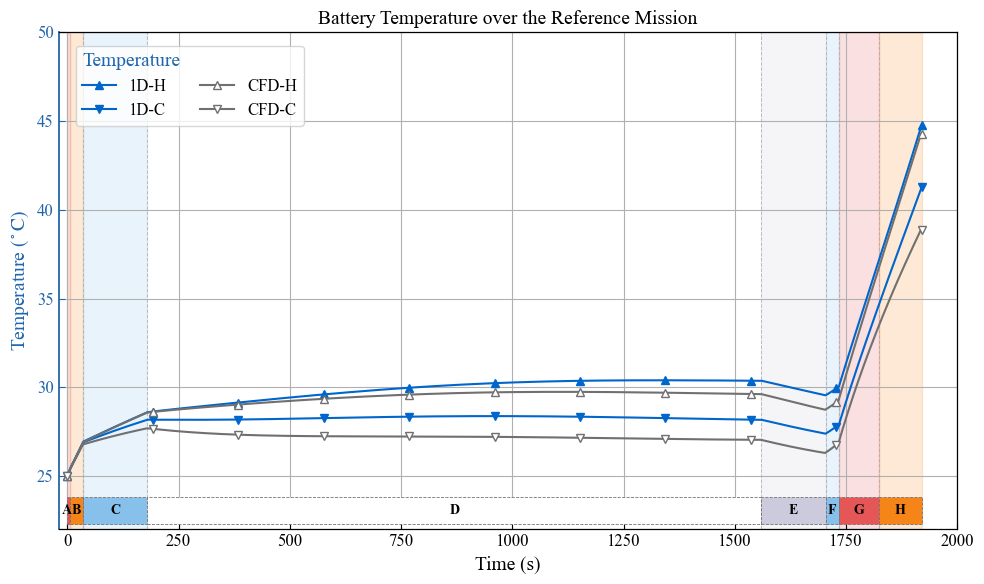

Saved temperature-curve figure: d:\eBATS\out\C0008\C0008R01_PARK25_AC_1D_EVAL.png
Saved temperature-curve figure: d:\eBATS\out\C0008\C0008R01_PARK25_AC_1D_EVAL.pdf


In [11]:
# plot and save the 1D and CFD maximum/minimum battery-temperature curves in the same style as C0016
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.transforms import blended_transform_factory

os.makedirs(OUTPUT_DIR, exist_ok=True)
figure_path = os.path.join(OUTPUT_DIR, RESULT_FIGURE_NAME)
figure_path_pdf = os.path.splitext(figure_path)[0] + '.pdf'

font_size = 12
stage_boundaries = [6.0, 36.0, 180.0, 1560.0, 1704.0, 1734.0, 1824.0, 1920.0]
stage_names = ['A: Take-off', 'B: Ascent Transition', 'C: Acceleration', 'D: Cruise', 'E: Deceleration', 'F: Descent Transition', 'G: Hovering', 'H: Landing']
stages_bgcolors = ['#E45756', '#F58518', '#87c1eb', '#FFFFFF', '#CBCBDD', '#87c1eb', '#E45756', '#F58518']

plt.rcdefaults()
plt.rcParams.update({'font.family': 'Times New Roman', 'mathtext.fontset': 'stix', 'font.size': font_size, 'axes.labelsize': font_size, 'axes.titlesize': font_size, 'xtick.labelsize': font_size, 'ytick.labelsize': font_size, 'axes.linewidth': 0.9, 'xtick.direction': 'in', 'ytick.direction': 'in', 'xtick.major.width': 0.8, 'ytick.major.width': 0.8, 'xtick.major.size': 4, 'ytick.major.size': 4, 'axes.unicode_minus': False})

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlim(-20, 2000)
all_temp_min = min(np.min(results['Tmin_C']), np.min(cfd_temperature_data['CFD_min']['temperature_C']), np.min(cfd_temperature_data['CFD_max']['temperature_C']))
all_temp_max = max(np.max(results['Tmax_C']), np.max(cfd_temperature_data['CFD_min']['temperature_C']), np.max(cfd_temperature_data['CFD_max']['temperature_C']))
y_min = min(22.0, np.floor(all_temp_min) - 1.0)
y_max = max(50.0, np.ceil(all_temp_max) + 1.0)
ax1.set_ylim(y_min, y_max)

alpha_band = 0.18
for i in range(len(stage_boundaries)):
    t_start = 0.0 if i == 0 else stage_boundaries[i - 1]
    t_end = stage_boundaries[i]
    ax1.axvspan(t_start, t_end, color=stages_bgcolors[i], alpha=alpha_band, zorder=0)

for boundary in stage_boundaries[1:-1]:
    ax1.axvline(boundary, color='0.65', linewidth=0.7, linestyle='--', alpha=0.7, zorder=1)

trans = blended_transform_factory(ax1.transData, ax1.transAxes)
bar_bottom = 0.01
bar_height = 0.055

for i, name in enumerate(stage_names):
    t_start = 0.0 if i == 0 else stage_boundaries[i - 1]
    t_end = stage_boundaries[i]
    t_mid = 0.5 * (t_start + t_end)
    duration = t_end - t_start
    offset = 5.0 if i == 0 else 0.0
    rect = Rectangle((t_start, bar_bottom), duration, bar_height, transform=trans, facecolor=stages_bgcolors[i], edgecolor='0.45', linewidth=0.6, linestyle='--', clip_on=False, zorder=10, alpha=1.0)
    ax1.add_patch(rect)
    ax1.text(t_mid - offset, bar_bottom + 0.5 * bar_height, name.split(':')[0], transform=trans, ha='center', va='center', rotation=0, fontsize=font_size - 2, fontweight='bold', color='black', clip_on=False, zorder=11)

left_style = {
    '1D_MIN': dict(label='1D-C', color='#0066CC', ls='-', marker='v'),
    '1D_MAX': dict(label='1D-H', color='#0066CC', ls='-', marker='^'),
    'CFD_MIN': dict(label='CFD-C', color='#707070', ls='-', marker='v', markerfacecolor='white'),
    'CFD_MAX': dict(label='CFD-H', color='#707070', ls='-', marker='^', markerfacecolor='white')
}
left_color = '#2166AC'
mark_number = 10
mark_spacing_1d = max(1, len(results['time_s']) // mark_number)
mark_spacing_cfd_max = max(1, len(cfd_temperature_data['CFD_max']) // mark_number)
mark_spacing_cfd_min = max(1, len(cfd_temperature_data['CFD_min']) // mark_number)

ax1.plot(results['time_s'], results['Tmax_C'], markevery=mark_spacing_1d, **left_style['1D_MAX'])
ax1.plot(results['time_s'], results['Tmin_C'], markevery=mark_spacing_1d, **left_style['1D_MIN'])
ax1.plot(cfd_temperature_data['CFD_max']['time_s'], cfd_temperature_data['CFD_max']['temperature_C'], markevery=mark_spacing_cfd_max, **left_style['CFD_MAX'])
ax1.plot(cfd_temperature_data['CFD_min']['time_s'], cfd_temperature_data['CFD_min']['temperature_C'], markevery=mark_spacing_cfd_min, **left_style['CFD_MIN'])

ax1.set_xlabel('Time (s)', fontsize=font_size + 2)
ax1.set_ylabel(r'Temperature ($^\circ\mathrm{C}$)', color=left_color, fontsize=font_size + 2)
ax1.tick_params(axis='y', colors=left_color)
ax1.spines['left'].set_color(left_color)
ax1.spines['left'].set_linewidth(1.3)
ax1.set_title('Battery Temperature over the Reference Mission', fontsize=font_size + 2)

handles_left, labels_left = ax1.get_legend_handles_labels()
handle_order = [0, 1, 2, 3]
handles_left = [handles_left[i] for i in handle_order]
labels_left = [labels_left[i] for i in handle_order]

leg1 = ax1.legend(handles_left, labels_left, loc='upper left', bbox_to_anchor=(0.01, 0.99), ncol=2, fontsize=font_size, alignment='left')
leg1.set_title(r'Temperature', prop={'size': font_size + 2})
leg1.get_title().set_color(left_color)

ax1.grid()
plt.tight_layout()
plt.savefig(figure_path, dpi=600, bbox_inches='tight')
plt.savefig(figure_path_pdf, dpi=600, bbox_inches='tight')
plt.show()

print(f'Saved temperature-curve figure: {figure_path}')
print(f'Saved temperature-curve figure: {figure_path_pdf}')